## Models

Models can be utilized in two ways:

    With agents - Models can be dynamically specified when creating an agent.
    Standalone - Models can be called directly (outside of the agent loop) for tasks like text generation, classification, or extraction without the need for an agent framework.

The same model interface works in both contexts, which gives you the flexibility to start simple and scale up to more complex agent-based workflows as needed.

### Initialize a model

The easiest way to get started with a standalone model in LangChain is to use init_chat_model to initialize one from a chat model provider of your choice (examples below):

` import os `
` from langchain.chat_models import init_chat_model `

` os.environ["OPENAI_API_KEY"] = "sk-..."`

` model = init_chat_model("gpt-5.4")`

In [2]:
import os
from langchain.chat_models import init_chat_model

os.environ["OPENAI_API_KEY"] = "sk-..."

model = init_chat_model("gpt-5.4")

In [1]:
import os
from langchain.chat_models import init_chat_model
model = init_chat_model(
    "auto",
    model_provider="openrouter",
    # Kwargs passed to the model:
    temperature=0.7,
    timeout=30,
    max_tokens=1000,
    max_retries=6,  # Default; increase for unreliable networks
)

/home/harsh.dhandha@simform.dom/hh/GenAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
response = model.invoke("Why do parrots talk?")
print(response.content)

KeyboardInterrupt: 

In [6]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    max_retries=10,  # Increase for unreliable networks (default: 6)
    timeout=120,  # Seconds; increase for slow connections
)

In [5]:
response = model.invoke("Why do parrots talk?")
print(response.content)

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite
Please retry in 55.447532364s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash-lite"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
,

KeyboardInterrupt: 

### Invocation

The most straightforward way to call a model is to use invoke() with a single message or a list of messages.


In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-5-nano",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
)

In [ ]:
conversation = [
    {"role": "system", "content": "You are a helpful assistant that translates English to French."},
    {"role": "user", "content": "Translate: I love programming."},
    {"role": "assistant", "content": "J'adore la programmation."},
    {"role": "user", "content": "Translate: I love building applications."}
]

response = model.invoke(conversation)
print(response) 

content="J'adore créer des applications." additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019e3eb8-572c-7952-8588-3d4ce76a8cec-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 34, 'output_tokens': 7, 'total_tokens': 41, 'input_token_details': {'cache_read': 0}}


In [9]:
from langchain.messages import HumanMessage, AIMessage, SystemMessage

conversation = [
    SystemMessage("You are a helpful assistant that translates English to French."),
    HumanMessage("Translate: I love programming."),
    AIMessage("J'adore la programmation."),
    HumanMessage("Translate: I love building applications.")
]

response = model.invoke(conversation)
print(response)

content="J'adore créer des applications." additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019e3eb8-6125-7bb0-b236-c5a2471113f9-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 34, 'output_tokens': 7, 'total_tokens': 41, 'input_token_details': {'cache_read': 0}}


### Stream

Most models can stream their output content while it is being generated. By displaying output progressively, streaming significantly improves user experience, particularly for longer responses.

In [10]:
for chunk in model.stream("Why do parrots have colorful feathers?"):
    print(chunk.text, end="|", flush=True)

Parrots have| colorful feathers for a variety of fascinating reasons, primarily related to **survival and reproduction**. Here's a| breakdown of the key factors:

**1. Communication and Social Signaling:**

* **Mate Attraction:** This is arguably the most significant reason. Bright, vibrant colors are often a sign of good health, a strong immune system, and good genes|. Potential mates are more likely to be attracted to individuals with striking plumage, as they are perceived as more desirable and likely to produce healthy offspring.
* **Species Recognition:** In dense rainforests where visual cues can be challenging, distinct color| patterns help parrots identify members of their own species. This is crucial for finding mates, forming flocks, and avoiding interbreeding.
* **Social Status and Dominance:** Certain color patterns or the intensity of colors can signal an individual's social rank| within a flock. This can help reduce aggression and establish a pecking order.
* **Mood and E

In [11]:
full = None  # None | AIMessageChunk
for chunk in model.stream("What color is the sky?"):
    full = chunk if full is None else full + chunk
    print(full.text)

# The
# The sky
# The sky is
# The sky is typically
# The sky is typically blue
# ...

print(full.content_blocks)
# [{"type": "text", "text": "The sky is typically blue..."}]

The sky is **blue**
The sky is **blue** during the day.

However, it's important to remember that the sky isn
The sky is **blue** during the day.

However, it's important to remember that the sky isn't *always* blue. Its color can change depending on several factors:

*   **Time of day:** At sunrise and sunset, the sky can appear shades of **red, orange, yellow, and pink** due to the scattering of sunlight
The sky is **blue** during the day.

However, it's important to remember that the sky isn't *always* blue. Its color can change depending on several factors:

*   **Time of day:** At sunrise and sunset, the sky can appear shades of **red, orange, yellow, and pink** due to the scattering of sunlight through more of the atmosphere.
*   **Weather:** Clouds can make the sky appear **white, gray, or even dark gray** before a storm.
*   **Pollution or dust:** These can also affect the sky's color
The sky is **blue** during the day.

However, it's important to remember that the sky isn't *a

In [12]:
async for event in model.astream_events("Hello"):

    if event["event"] == "on_chat_model_start":
        print(f"Input: {event['data']['input']}")

    elif event["event"] == "on_chat_model_stream":
        print(f"Token: {event['data']['chunk'].text}")

    elif event["event"] == "on_chat_model_end":
        print(f"Full message: {event['data']['output'].text}")

    else:
        pass

Input: Hello
Token: Hello!
Token:  How can I help you today?
Token: 
Full message: Hello! How can I help you today?


#### "Auto-streaming" chat models

- LangChain simplifies streaming from chat models by automatically enabling streaming mode in certain cases, even when you’re not explicitly calling the streaming methods. This is particularly useful when you use the non-streaming invoke method but still want to stream the entire application, including intermediate results from the chat model.In LangGraph agents, for example, you can call model.invoke() within nodes, but LangChain will automatically delegate to streaming if running in a streaming mode.
​

    How it works

- When you invoke() a chat model, LangChain will automatically switch to an internal streaming mode if it detects that you are trying to stream the overall application. The result of the invocation will be the same as far as the code that was using invoke is concerned; however, while the chat model is being streamed, LangChain will take care of invoking on_llm_new_token events in LangChain’s callback system.Callback events allow LangGraph stream() and astream_events() to surface the chat model’s output in real-time.

In [13]:
responses = model.batch([
    "Why do parrots have colorful feathers?",
    "How do airplanes fly?",
    "What is quantum computing?"
])
for response in responses:
    print(response)

content="Parrots have colorful feathers for a variety of reasons, and it's a fascinating interplay of **evolution, communication, and survival**. Here's a breakdown of the key factors:\n\n**1. Mate Attraction and Sexual Selection:**\n\n* **Visual Displays:** This is arguably the most significant reason. In many parrot species, the most vibrant and striking colors are found in males. These bright displays act as a visual advertisement to females, signaling their health, fitness, and genetic quality. A parrot with brilliant plumage is likely well-nourished, free from parasites, and has a strong immune system.\n* **Species Recognition:** Distinct color patterns help parrots recognize individuals of their own species, preventing mating with unsuitable partners and ensuring successful reproduction.\n* **Courtship Rituals:** The colors are often accentuated during courtship displays, where parrots might puff up their feathers, spread their wings, and perform elaborate dances to impress poten

By default, batch() will only return the final output for the entire batch. If you want to receive the output for each individual input as it finishes generating, you can stream results with batch_as_completed():

In [2]:
from langchain_openai import ChatOpenAI
model = ChatOpenAI(
    model="gpt-5-nano",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
)

In [3]:
for response in model.batch_as_completed([
    "Why do parrots have colorful feathers?",
    "How do airplanes fly?",
    "What is quantum computing?"
]):
    print(response)

(0, AIMessage(content='Parrots have colorful feathers mainly for two reasons:\n\n1) Communication and social signals: Bright colors help parrots recognize mates, other members of their flock, and show dominance or submission. They also help individuals stand out to potential mates during courtship.\n\n2) Camouflage and environment: In many tropical forests, vivid colors can blend with the bright flowers, fruits, and foliage, helping parrots blend into their surroundings or distract predators. Some colors also warn or confuse predators.\n\nAdditionally, color comes from:\n- Pigments (like psittacofulvins in parrots, which create reds, oranges, pinks, and yellows).\n- Structural coloration (microstructures that create blues and greens by interfering light).\n\nSo, bright plumage serves social communication and, in some contexts, camouflage, with the colors produced by both pigments and structural effects.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completi

When processing a large number of inputs using batch() or batch_as_completed(), you may want to control the maximum number of parallel calls. This can be done by setting the max_concurrency attribute in the RunnableConfig dictionary.

```
 model.batch(
    list_of_inputs,
    config={
        'max_concurrency': 5,  # Limit to 5 parallel calls
    }
) 

### Tool calling

 Tools are pairings of:

   -  A schema, including the name of the tool, a description, and/or argument definitions (often a JSON schema)
   -  A function or coroutine to execute.


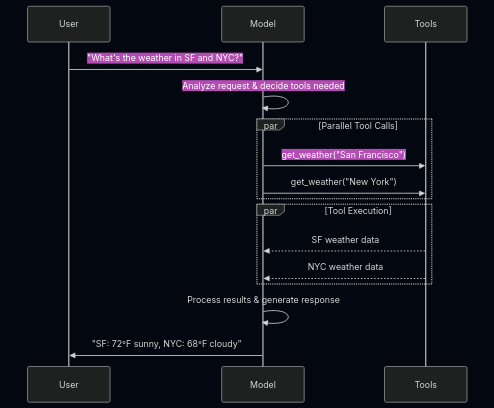

In [9]:
from langchain.tools import tool

@tool
def get_weather(location: str) -> str:
    """Get the weather at a location."""
    return f"It's sunny in {location}."


model_with_tools = model.bind_tools([get_weather])

response = model_with_tools.invoke("What's the weather like in Boston?")
for tool_call in response.tool_calls:
    # View tool calls made by the model
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

Tool: get_weather
Args: {'location': 'Boston'}


#### Tool execution loop

When a model returns tool calls, you need to execute the tools and pass the results back to the model. This creates a conversation loop where the model can use tool results to generate its final response. LangChain includes agent abstractions that handle this orchestration for you

In [12]:
model_with_tools = model.bind_tools([get_weather])

messages = [{"role": "user", "content": "What's the weather in Ahmedabad? (with degree celcius)"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

for tool_call in ai_msg.tool_calls:
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

final_repsonse = model_with_tools.invoke(messages)
print(final_repsonse.text)

The current weather in Ahmedabad is sunny. It didn’t provide a temperature in Celsius yet. If you’d like, I can fetch an updated temperature in °C for Ahmedabad.


Each ToolMessage returned by the tool includes a tool_call_id that matches the original tool call, helping the model correlate results with requests.

#### Forcing tool calls

In [ ]:
model_with_tools = model.bind_tools([tool_1], tool_choice="any")

#### Parallel tool calls

In [13]:
model_with_tools = model.bind_tools([get_weather])

response = model_with_tools.invoke(
    "What's the weather in Boston and Tokyo?"
)


# The model may generate multiple tool calls
print(response.tool_calls)
# [
#   {'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': 'call_1'},
#   {'name': 'get_weather', 'args': {'location': 'Tokyo'}, 'id': 'call_2'},
# ]


# Execute all tools (can be done in parallel with async)
results = []
for tool_call in response.tool_calls:
    if tool_call['name'] == 'get_weather':
        result = get_weather.invoke(tool_call)
    ...
    results.append(result)

[{'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': 'call_fZokBXAr0QHTCbeD6tNWly9e', 'type': 'tool_call'}, {'name': 'get_weather', 'args': {'location': 'Tokyo'}, 'id': 'call_FWgbrS9M7V5vXc6MS6BqlypO', 'type': 'tool_call'}]


In [14]:
model.bind_tools([get_weather], parallel_tool_calls=False)

_ChatModelBinding(bound=ChatOpenAI(output_version=None, profile={'name': 'GPT-5 Nano', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x76b838943e60>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x76b83445fa70>, root_client=<openai.OpenAI object at 0x76b83445fd40>, root_async_client=<openai.AsyncOpenAI object at 0x76b8387e7230>, model_name='gpt-5-nano', model_kwar

In [15]:
model_with_tools = model.bind_tools([get_weather])

response = model_with_tools.invoke(
    "What's the weather in Boston and Tokyo?"
)


# The model may generate multiple tool calls
print(response.tool_calls)
# [
#   {'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': 'call_1'},
#   {'name': 'get_weather', 'args': {'location': 'Tokyo'}, 'id': 'call_2'},
# ]


# Execute all tools (can be done in parallel with async)
results = []
for tool_call in response.tool_calls:
    if tool_call['name'] == 'get_weather':
        result = get_weather.invoke(tool_call)
    ...
    results.append(result)

[{'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': 'call_UJuf7scXOk9beCR3StNcT5xq', 'type': 'tool_call'}]


#### Streaming tool calls

Models can be requested to provide their response in a format matching a given schema. This is useful for ensuring the output can be easily parsed and used in subsequent processing. LangChain supports multiple schema types and methods for enforcing structured output.

#### Pydantic

In [18]:
from pydantic import BaseModel, Field

class movie(BaseModel):
    """ A movie with details"""
    title: str = Field(description="The title of the movie")
    year: int = Field(description="The year the mvoie was released")
    director: str = Field(description="The director of the movie")
    rating: float = Field(description="The movie's rating out of 10")

model_with_structure =  model.with_structured_output(movie, include_raw=True)
res = model_with_structure.invoke("Provide details about the movie Inception")

print(res)

{'raw': AIMessage(content='{"director":"Christopher Nolan","rating":8.8,"title":"Inception","year":2010}', additional_kwargs={'parsed': movie(title='Inception', year=2010, director='Christopher Nolan', rating=8.8), 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 123, 'total_tokens': 158, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Dh8KUrEyPVCM9AepZa22XdZEouYRK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3ef1-ca99-7142-81ad-22ea478f8db4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 123, 'output_tokens': 35, 'total_tokens': 158, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_

#### Json

In [17]:
import json

json_schema = {
    "title": "Movie",
    "description": "A movie with details",
    "type": "object",
    "properties": {
        "title": {
            "type": "string",
            "description": "The title of the movie"
        },
        "year": {
            "type": "integer",
            "description": "The year the movie was released"
        },
        "director": {
            "type": "string",
            "description": "The director of the movie"
        },
        "rating": {
            "type": "number",
            "description": "The movie's rating out of 10"
        }
    },
    "required": ["title", "year", "director", "rating"]
}

model_with_structure = model.with_structured_output(
    json_schema,
    method="json_schema",
)
response = model_with_structure.invoke("Provide details about the movie Inception")
print(response)  # {'title': 'Inception', 'year': 2010, ...}

{'title': 'Inception', 'year': 2010, 'director': 'Christopher Nolan', 'rating': 8.8}


In [19]:
from pydantic import BaseModel, Field

class Actor(BaseModel):
    name: str
    role: str

class MovieDetails(BaseModel):
    title: str
    year: int
    cast: list[Actor]
    genres: list[str]
    budget: float | None = Field(None, description="Budget in millions USD")

model_with_structure = model.with_structured_output(MovieDetails)

In [20]:
response = model_with_structure.invoke("Provide details about the movie Inception")
print(response)

title='Inception' year=2010 cast=[Actor(name='Leonardo DiCaprio', role='Dom Cobb'), Actor(name='Joseph Gordon-Levitt', role='Arthur'), Actor(name='Elliot Page', role='Ariadne'), Actor(name='Tom Hardy', role='Eames'), Actor(name='Ken Watanabe', role='Saito'), Actor(name='Dilip Rao', role='Robert Fischer (adult)')] genres=['Action', 'Adventure', 'Sci-Fi'] budget=160.0


### Model profiles

```
model.profile
# {
#   "max_input_tokens": 400000,
#   "image_inputs": True,
#   "reasoning_output": True,
#   "tool_calling": True,
#   ...
# }

Much of the model profile data is powered by the models.dev project, an open source initiative that provides model capability data. These data are augmented with additional fields for purposes of use with LangChain. These augmentations are kept aligned with the upstream project as it evolves. Model profile data allow applications to work around model capabilities dynamically. For example:

    Summarization middleware can trigger summarization based on a model’s context window size.
    Structured output strategies in create_agent can be inferred automatically (e.g., by checking support for native structured output features).
    Model inputs can be gated based on supported modalities and maximum input tokens.
    Deep Agents Code filters the interactive model switcher to models whose profiles report tool_calling support and text I/O, and displays context window sizes and capability flags in the selector detail view.


### Multimodal

In [21]:
response = model.invoke("Create a picture of a cat")
print(response.content_blocks)
# [
#     {"type": "text", "text": "Here's a picture of a cat"},
#     {"type": "image", "base64": "...", "mime_type": "image/jpeg"},
# ]

[{'type': 'text', 'text': "Here are a few simple cat pictures you can choose from. Let me know if you want a different style or size.\n\nOption 1: Cute cartoon cat\n /\\_/\\  \n( o.o ) \n > ^ <\n\nOption 2: More detailed ASCII cat\n /\\_/\\  \n(='.'=)\n(,SE,)\n\nOption 3: Sleepy cat\n /\\_/\\ \n( -.- ) zzz…\n\nOption 4: Pixel-style cat\n  /\\_/\\  \n ( •.• ) \n  > ^ <\n\nIf you’d like a digital image or a specific pose/color, tell me and I can generate something closer to what you want."}]


### Reasoning

In [4]:
for chunk in model.stream("Why do parrots have colorful feathers?"):
    reasoning_steps = [r for r in chunk.content_blocks if r["type"] == "reasoning"]
    print(reasoning_steps if reasoning_steps else chunk.text)



Par
rots
 have
 colorful
 feathers
 mainly
 for
 three
 reasons
:


-
 Cam
ouflage
 and
 habitat
 communication
:
 In
 tropical
 forests
,
 d
apple
d
 light
 and
 bright
 flowers
 mean
 vivid
 colors
 help
 parro
ts
 blend
 with
 flowers
,
 fruit
,
 and
 foliage
 when
 seen
 by
 others
 of
 their
 species
.
 Bright
 patches
 can
 also
 help
 individuals
 recognize
 each
 other
 in
 dense
 forests
.


-
 Mate
 attraction
 and
 signaling
:
 Bright
,
 varied
 colors
 are
 often
 used
 to
 attract
 mates
.
 More
 vibrant
 plum
age
 can
 indicate
 good
 health
,
 good
 genes
,
 and
 a
 strong
 computer
 of
 fitness
,
 so
 individuals
 with
 brighter
 colors
 may
 have
 higher
 breeding
 success
.


-
 Social
 and
 species
 recognition
:
 Dist
inct
 color
 patterns
 help
 parro
ts
 identify
 members
 of
 their
 own
 species
 and
 even
 their
 social
 group
 or
 flock
,
 which
 is
 important
 for
 flock
 coordination
 and
 mating
.


How
 coloration
 develops
:

-
 Pig
ments
:
 Car
ot
eno
i

In [9]:
from langchain.chat_models import init_chat_model

from langchain_openai import ChatOpenAI
model = ChatOpenAI(
    model="gpt-5-mini",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
)
tool = {"type": "web_search"}
model_with_tools = model.bind_tools([tool])

response = model_with_tools.invoke("What was cricket news from today?")
print(response.content_blocks)

PermissionDeniedError: Error code: 403 - {'error': {'message': '免费API限制使用deepseek-r1, deepseek-v3, gpt-3.5-turbo, gpt-4o-mini, gpt-4o, gpt-4.1-mini, gpt-4.1-nano, gpt-4.1, gpt-5-mini, gpt-5-nano, gpt-5和embeddings模型，如有更多需求，请访问 https://api.chatanywhere.tech/#/shop 购买付费API。The free account is limited to use deepseek-r1, deepseek-v3, gpt-3.5-turbo, gpt-4o-mini, gpt-4o and embeddings. If you have additional requirements, please visit https://api.chatanywhere.tech/#/shop to purchase a premium key.(当前请求使用的ApiKey: sk-3NN****Tl5Z)【如果您遇到问题，欢迎加入QQ群咨询：625105715】', 'type': 'chatanywhere_error', 'param': None, 'code': '403 FORBIDDEN'}}

In [11]:
from langchain_core.rate_limiters import InMemoryRateLimiter

rate_limiter = InMemoryRateLimiter(
    requests_per_second=0.1,  # 1 request every 10s
    check_every_n_seconds=0.1,  # Check every 100ms whether allowed to make a request
    max_bucket_size=10,  # Controls the maximum burst size.
)
model = ChatOpenAI(
    model="gpt-5-mini",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
    rate_limiter=rate_limiter
)
model.invoke("what is latest date u are updated ?")

AIMessage(content='My training knowledge goes up to June 2024. I can access no real-time web data, so anything after that I may not know unless you provide details.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 14, 'total_tokens': 57, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini', 'system_fingerprint': None, 'id': 'chatcmpl-DhBRWefmn09IyUVw5ZQBBKPbEdUD0', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3fa8-3c16-7133-82aa-348b5ee36d57-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 43, 'total_tokens': 57, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [14]:
model = init_chat_model(
    model="gpt-5-mini",
    model_provider="openai",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
)
response = model.invoke("what is langchain")
print(response.content)

LangChain is an open-source framework designed to help developers build applications that use large language models (LLMs) in useful, production-ready ways. Instead of treating an LLM as a single “call this model and return the text” box, LangChain provides building blocks and abstractions to integrate models into broader workflows and systems.

Key ideas and components:
- Prompt management: Tools to create, store, and format prompts (templates, prompt chaining, prompt serialization).
- Model interfaces: Standardized connectors for different LLM providers (OpenAI, Anthropic, Hugging Face, local models, etc.), plus utilities for streaming, batching, and response parsing.
- Chains: Composable sequences of steps (prompt → LLM → post-process → tool call → memory, etc.) so you can build multi-step flows.
- Tools and agents: Mechanisms to let an LLM call external tools (APIs, search, calculators) and to orchestrate decision-making (agents that choose tools/actions based on model outputs).
- 

In [ ]:
model = init_chat_model(
    model="gpt-5-mini",
    model_provider="openai",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
).bind(logprobs=True)

response = model.invoke("Why do parrots talk?")
print(response.response_metadata["logprobs"])

None


#### Callback handler


In [ ]:
from langchain.chat_models import init_chat_model
from langchain_core.callbacks import UsageMetadataCallbackHandler

model_1 = init_chat_model(model="gpt-5.4-mini",    
                          model_provider="openai",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"))
model_2 = init_chat_model(model="openai/gpt-oss-20b", 
                          model_provider="openrouter")

callback = UsageMetadataCallbackHandler()
result_1 = model_1.invoke("Hello", config={"callbacks": [callback]})
result_2 = model_2.invoke("Hello", config={"callbacks": [callback]})
print(callback.usage_metadata)

{'gpt-5.4-mini-2026-03-17': {'input_tokens': 7, 'output_tokens': 13, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}, 'openai/gpt-oss-20b': {'input_tokens': 68, 'output_tokens': 38, 'total_tokens': 106, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'reasoning': 20}}}


#### context manager

In [17]:
from langchain.chat_models import init_chat_model
from langchain_core.callbacks import get_usage_metadata_callback

model_1 = init_chat_model(model="gpt-5.4-mini",    
                          model_provider="openai",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"))
model_2 = init_chat_model(model="openai/gpt-oss-20b", 
                          model_provider="openrouter")
with get_usage_metadata_callback() as cb:
    model_1.invoke("Hello")
    model_2.invoke("Hello")
    print(cb.usage_metadata)

{'gpt-5.4-mini-2026-03-17': {'input_tokens': 7, 'output_tokens': 13, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}, 'openai/gpt-oss-20b': {'input_tokens': 55, 'output_tokens': 57, 'total_tokens': 112, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'reasoning': 39}}}


In [18]:
response = model.invoke(
    "Tell me a joke",
    config={
        "run_name": "joke_generation",      # Custom name for this run
        "tags": ["humor", "demo"],          # Tags for categorization
        "metadata": {"user_id": "123"},     # Custom metadata
        "callbacks": [callback], # Callback handlers
    }
)

In [20]:
print(response)

content='Why did the scarecrow win an award?\n\nBecause he was outstanding in his field.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 10, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini', 'system_fingerprint': None, 'id': 'chatcmpl-DhBhXH25wYjR3WerlocDz8Gf4bFbE', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e3fb7-8b4e-7253-987a-11ca3dcf52e4-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 10, 'output_tokens': 27, 'total_tokens': 37, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


## Messages

Messages are the fundamental unit of context for models in LangChain. They represent the input and output of models, carrying both the content and metadata needed to represent the state of a conversation when interacting with an LLM. 

Messages are objects that contain:

    - Role - Identifies the message type (e.g. system, user)
    - Content - Represents the actual content of the message (like text, images, audio, documents, etc.)
    - Metadata - Optional fields such as response information, message IDs, and token usage


In [ ]:
model = init_chat_model(model="gpt-5.4-mini",    
                          model_provider="openai",
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"))

### Basic usage

In [21]:
from langchain.messages import HumanMessage, AIMessage, SystemMessage

system_msg = SystemMessage("You are an helpful assistant")
humna_msg = HumanMessage("Hello , how are u ?")

messages = [ system_msg, humna_msg]
res=model.invoke(messages)

In [22]:
print(res)

content="Hi — I'm doing well, thanks! How are you? How can I help today?" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 21, 'total_tokens': 49, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini', 'system_fingerprint': None, 'id': 'chatcmpl-DhC6rhbJIf8brHySHVEoju6fiQTtc', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e3fcf-7d32-78e3-a4f4-571c36b42ed1-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 21, 'output_tokens': 28, 'total_tokens': 49, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


#### Text prompts

Text prompts are strings - ideal for straightforward generation tasks where you don’t need to retain conversation history.

#### Message prompts

In [23]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage

messages = [
    SystemMessage("You are a poetry expert"),
    HumanMessage("Write a haiku about spring"),
    AIMessage("Cherry blossoms bloom...")
]
response = model.invoke(messages)

In [24]:
print(response)

content='Soft rain wakes the buds —\ngreen whispers along the lane,\nsparrows stitch the light.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 31, 'total_tokens': 59, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DhCKQgjpX4hTKnTcZfJsGSwvaYFBl', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e3fdc-4f0f-77d0-b03f-526909185810-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 31, 'output_tokens': 28, 'total_tokens': 59, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


#### Dictionary format

In [25]:
messages = [
    {"role": "system", "content": "You are a poetry expert"},
    {"role": "user", "content": "Write a haiku about spring"},
    {"role": "assistant", "content": "Cherry blossoms bloom..."}
]
response = model.invoke(messages)

#### System message

In [26]:
system_msg = SystemMessage("You are a helpful coding assistant.")

messages = [
    system_msg,
    HumanMessage("How do I create a REST API?")
]
response = model.invoke(messages)

In [27]:
print(response)

content='Creating a REST API involves designing HTTP endpoints that expose resources, implementing those endpoints on a server, and handling requests and responses in a standard way. Below is a practical, technology-agnostic guide plus short examples in two popular stacks (Node.js/Express and Python/Flask) so you can start quickly.\n\nOverview — key concepts\n- Resources: the entities your API exposes (users, posts, orders).\n- URIs: each resource or collection has a URL (e.g., /users, /users/{id}).\n- HTTP methods:\n  - GET to read,\n  - POST to create,\n  - PUT or PATCH to update,\n  - DELETE to remove.\n- Status codes: indicate result (200/201/204/400/401/404/500).\n- Representations: usually JSON.\n- Stateless: server does not keep client state between requests.\n- Versioning: include version in the path or headers (e.g., /v1/users).\n- Authentication & authorization: e.g., API keys, OAuth, JWT.\n- Documentation: OpenAPI/Swagger helps clients use your API.\n- Validation & error han

In [28]:
from langchain.messages import SystemMessage, HumanMessage

system_msg = SystemMessage("""
You are a senior Python developer with expertise in web frameworks.
Always provide code examples and explain your reasoning.
Be concise but thorough in your explanations.
""")

messages = [
    system_msg,
    HumanMessage("How do I create a REST API?")
]
response = model.invoke(messages)
print(response)

content='Creating a REST API means designing HTTP endpoints that let clients create, read, update, and delete resources over the web in a predictable way. I\'ll give you a concise, practical guide with examples in two popular Python frameworks (Flask and FastAPI), explain key design decisions, and show testing and deployment basics.\n\nHigh-level steps\n1. Define resources and operations. Decide what resources (users, posts, products) and which HTTP methods map to operations (GET, POST, PUT/PATCH, DELETE).\n2. Design URL structure and payloads. Use plural nouns (/users, /posts/{id}), consistent naming, and JSON payloads.\n3. Choose a framework and tools. Examples below use Flask (microframework) and FastAPI (modern, async, built-in OpenAPI).\n4. Implement handlers, validation, authentication, and errors.\n5. Add tests, docs, and deploy.\n\nKey design guidelines\n- Use nouns (not verbs) for endpoints: GET /books, POST /books.\n- Use standard HTTP status codes: 200 OK, 201 Created (on PO

### Human message

A HumanMessage represents user input and interactions. They can contain text, images, audio, files, and any other amount of multimodal content.

#### Text content

In [ ]:
response = model.invoke([
  HumanMessage("What is machine learning?")
])

#### Message metadata

In [29]:
human_msg = HumanMessage(
    content="Hello!",
    name="alice",  # Optional: identify different users
    id="msg_123",  # Optional: unique identifier for tracing
)

### AI MEssage

An AIMessage represents the output of a model invocation. They can include multimodal data, tool calls, and provider-specific metadata that you can later access.

In [30]:
response = model.invoke("Explain AI")
print(type(response))  # <class 'langchain.messages.AIMessage'>

<class 'langchain_core.messages.ai.AIMessage'>


AIMessage objects are returned by the model when calling it, which contains all of the associated metadata in the response.

In [31]:
from langchain.messages import AIMessage, SystemMessage, HumanMessage

# Create an AI message manually (e.g., for conversation history)
ai_msg = AIMessage("I'd be happy to help you with that question!")

# Add to conversation history
messages = [
    SystemMessage("You are a helpful assistant"),
    HumanMessage("Can you help me?"),
    ai_msg,  # Insert as if it came from the model
    HumanMessage("Great! What's 2+2?")
]

response = model.invoke(messages)
print(response)

content='2 + 2 = 4' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 48, 'total_tokens': 65, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DhCnHHjPzaSgHGYueQ9sJWRCLjpHD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e3ff7-90ac-7483-bb25-9668bff39edb-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 48, 'output_tokens': 17, 'total_tokens': 65, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


#### Tool calls

In [32]:
from langchain.chat_models import init_chat_model


def get_weather(location: str) -> str:
    """Get the weather at a location."""
    ...

model_with_tools = model.bind_tools([get_weather])
response = model_with_tools.invoke("What's the weather in Paris?")

for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")
    print(f"ID: {tool_call['id']}")

Tool: get_weather
Args: {'location': 'Paris, France'}
ID: call_Zr6xIRVhcrbVdeQyOORZahgG


In [33]:
response.usage_metadata

{'input_tokens': 131,
 'output_tokens': 26,
 'total_tokens': 157,
 'input_token_details': {'audio': 0, 'cache_read': 0},
 'output_token_details': {'audio': 0, 'reasoning': 0}}

#### Streaming and chunks

In [34]:
chunks = []
full_message = None
for chunk in model.stream("Hi"):
    chunks.append(chunk)
    print(chunk.text)
    full_message = chunk if full_message is None else full_message + chunk



Hello
!
 How
 can
 I
 help
 you
 today
?





#### Tool message

In [35]:
from langchain.messages import AIMessage
from langchain.messages import ToolMessage

# After a model makes a tool call
# (Here, we demonstrate manually creating the messages for brevity)
ai_message = AIMessage(
    content=[],
    tool_calls=[{
        "name": "get_weather",
        "args": {"location": "San Francisco"},
        "id": "call_123"
    }]
)

# Execute tool and create result message
weather_result = "Sunny, 72°F"
tool_message = ToolMessage(
    content=weather_result,
    tool_call_id="call_123"  # Must match the call ID
)

# Continue conversation
messages = [
    HumanMessage("What's the weather in San Francisco?"),
    ai_message,  # Model's tool call
    tool_message,  # Tool execution result
]
response = model.invoke(messages)  # Model processes the result

In [36]:
print(response)

content="It's sunny in San Francisco and about 72°F right now. Would you like the forecast for today or the next few days, or any details like wind, humidity, or sunrise/sunset times?" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 47, 'total_tokens': 97, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini', 'system_fingerprint': None, 'id': 'chatcmpl-DhCvEaxdpCFOP5OIWch250XjuBAvF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e3fff-2858-7750-9148-6c10416cc7e0-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 47, 'output_tokens': 50, 'total_tokens': 97, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoni

##### artifact

The artifact field stores supplementary data that won’t be sent to the model but can be accessed programmatically. This is useful for storing raw results, debugging information, or data for downstream processing without cluttering the model’s context.

In [37]:
from langchain.messages import ToolMessage

# Sent to model
message_content = "It was the best of times, it was the worst of times."

# Artifact available downstream
artifact = {"document_id": "doc_123", "page": 0}

tool_message = ToolMessage(
    content=message_content,
    tool_call_id="call_123",
    name="search_books",
    artifact=artifact,
)

### Message content


In [38]:
from langchain.messages import HumanMessage

# String content
human_message = HumanMessage("Hello, how are you?")

# Provider-native format (e.g., OpenAI)
human_message = HumanMessage(content=[
    {"type": "text", "text": "Hello, how are you?"},
    {"type": "image_url", "image_url": {"url": "https://example.com/image.jpg"}}
])

# List of standard content blocks
human_message = HumanMessage(content_blocks=[
    {"type": "text", "text": "Hello, how are you?"},
    {"type": "image", "url": "https://example.com/image.jpg"},
])

In [39]:
from langchain.messages import AIMessage

message = AIMessage(
    content=[
        {
            "type": "reasoning",
            "id": "rs_abc123",
            "summary": [
                {"type": "summary_text", "text": "summary 1"},
                {"type": "summary_text", "text": "summary 2"},
            ],
        },
        {"type": "text", "text": "...", "id": "msg_abc123"},
    ],
    response_metadata={"model_provider": "openai"}
)
message.content_blocks

[{'type': 'reasoning', 'id': 'rs_abc123', 'reasoning': 'summary 1'},
 {'type': 'reasoning', 'id': 'rs_abc123', 'reasoning': 'summary 2'},
 {'type': 'text', 'text': '...', 'id': 'msg_abc123'}]

In [40]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-nano", 
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL"),
    output_version="v1")

model.invoke("hi")

AIMessage(content=[{'type': 'text', 'text': 'Hello! How can I help you today?'}], additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 7, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DhE6Av8DZNRYe7l1wmbBczLERe4Py', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None, 'output_version': 'v1'}, id='lc_run--019e4044-282b-73e0-8a3a-99159963f036-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 19, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

## Tools

Tools extend what agents can do—letting them fetch real-time data, execute code, query external databases, and take actions in the world.

### Create tools

#### Basic tool definition

In [41]:
from langchain.tools import tool

@tool
def search_database(query: str, limit: int = 10) -> str:
    """Search the customer database for records matching the query.

    Args:
        query: Search terms to look for
        limit: Maximum number of results to return
    """
    return f"Found {limit} results for '{query}'"

### Customize tool properties
#### Custom tool name

In [42]:
@tool("web_search")  # Custom name
def search(query: str) -> str:
    """Search the web for information."""
    return f"Results for: {query}"

print(search.name)  # web_search

web_search


#### Custom tool description

In [44]:
@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

#### Advanced schema definition


In [43]:
from pydantic import BaseModel, Field
from typing import Literal

class WeatherInput(BaseModel):
    """Input for weather queries."""
    location: str = Field(description="City name or coordinates")
    units: Literal["celsius", "fahrenheit"] = Field(
        default="celsius",
        description="Temperature unit preference"
    )
    include_forecast: bool = Field(
        default=False,
        description="Include 5-day forecast"
    )

@tool(args_schema=WeatherInput)
def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
    """Get current weather and optional forecast."""
    temp = 22 if units == "celsius" else 72
    result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
    if include_forecast:
        result += "\nNext 5 days: Sunny"
    return result

### Access Context

Tools are most powerful when they can access runtime information like conversation history, user data, and persistent memory. This section covers how to access and update this information from within your tools. Tools can access runtime information through the ToolRuntime parameter, which provides:

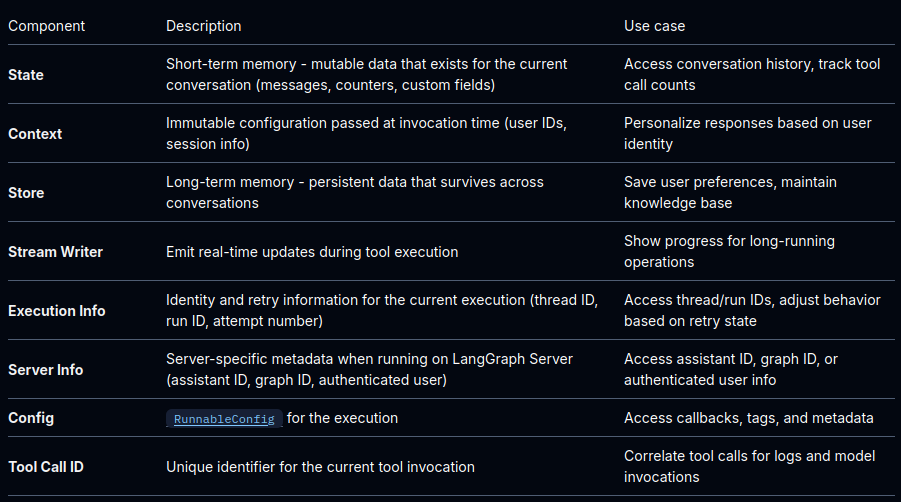

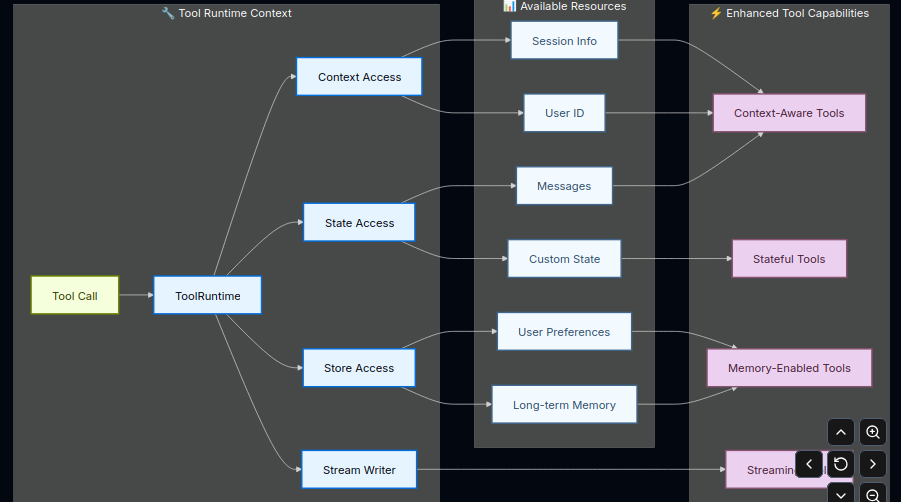

### Short-term memory (State)

State represents short-term memory that exists for the duration of a conversation. It includes the message history and any custom fields you define in your graph state.

#### Access state

Tools can access the current conversation state using runtime.state: